# 04 - CODE-15% exploratory data analysis

CODE-15% is a 15% sample of the CODE dataset from the Telehealth Network of Minas Gerais, Brazil:
345,779 exams from 233,770 patients, recorded at 400 Hz in primary care and sent for remote reading. Each
exam has age, sex, six diagnosis flags from an automatic system reviewed by cardiologists, an automatic
`normal_ecg` flag, a neural-network estimate of the patient's age from the ECG, and **mortality follow-up**.
This notebook describes the dataset: missing and wrong values, how diagnoses and death relate to age and
sex, and what the stored tracings contain.

`exams.csv` is read from `data/raw/code-15pct/`. The 18 waveform parts are streamed from the verified
archive in `outputs/data_export/`, one part at a time (it needs 68 GB unpacked), and cover all 345,797
stored tracings.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from ecg_experiment.eda.code15 import (
    LABELS,
    PREPARED_DIR,
    code15_summary,
    lead_features,
    load_exams,
    padding_table,
    read_native_tracing,
)
from ecg_experiment.eda.cross import combined_summary
from ecg_experiment.eda.ptbxl import load_metadata
from ecg_experiment.eda.ptbxl_signals import FEATURE_CACHE as PTBXL_FEATURES
from ecg_experiment.eda.signals import LEADS, plot_ecg, problem_counts
from ecg_experiment.eda.stats import age_band, odds_ratios, plot_prevalence, prevalence

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

exams = load_exams()
exams["male"] = exams["is_male"]
exams["sex"] = np.where(exams["male"], "male", "female")
exams["age_band"] = age_band(exams["age"])
exams["dead"] = exams["death"].map({True: 1.0, False: 0.0})
NAMES = {"1dAVb": "1st degree AV block", "RBBB": "right bundle branch block",
         "LBBB": "left bundle branch block", "SB": "sinus bradycardia", "ST": "sinus tachycardia",
         "AF": "atrial fibrillation"}

## 1. Missing values and patients

In [3]:
missing = exams.drop(columns=["dead"]).isna().mean()
display(missing[missing > 0].round(3).to_frame("missing fraction"))
per_patient = exams.groupby("patient_id").size()
display(pd.Series({
    "exams": len(exams),
    "patients": exams["patient_id"].nunique(),
    "patients with more than one exam": int((per_patient > 1).sum()),
    "most exams for one patient": int(per_patient.max()),
    "male share": exams["male"].mean(),
    "median age": exams["age"].median(),
    "age range": f"{exams['age'].min()}-{exams['age'].max()}",
}).to_frame("value"))
followed = exams["dead"].notna()
display(exams.groupby(followed)[["age", "male", "normal_ecg"]].mean().round(3)
        .rename(index={False: "no follow-up", True: "with follow-up"}))

,missing fraction
death,0.324
timey,0.324


,value
exams,345779
patients,233770
patients with more than one exam,66929
most exams for one patient,38
male share,0.403
median age,54.0
age range,17-100


,age,male,normal_ecg
dead,,,
no follow-up,58.45,0.397,0.379
with follow-up,50.74,0.405,0.394


**Finding.** Only the survival fields (`death`, `timey`) are missing, for 32% of exams, and **not at random**:
exams without follow-up are older (mean age 58 vs 51), although sex and the share of normal ECGs are the same.
The follow-up subset is therefore younger than the full dataset, and its mortality rates understate the risk
of the whole population somewhat. 29% of patients have repeat exams (up to 38), so patients, not exams, are the
independent unit. Ages run from 17 to 100 with no placeholders. The population is younger (median 54) and
mostly female (60%), unlike the hospital datasets.

## 2. Labels, age and sex

any of the six flags,False,True,All
normal_ecg,,,
False,173347,37775,211122
True,134657,0,134657
All,308004,37775,345779


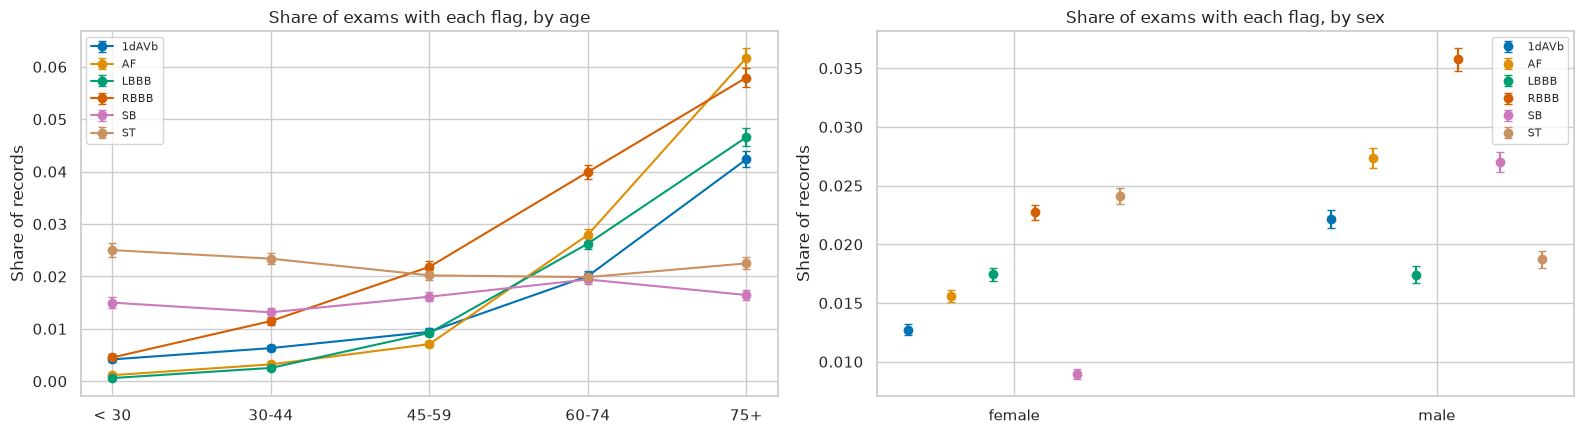

outcome,1dAVb,RBBB,LBBB,SB,ST,AF,normal_ecg
age_band,,,,,,,
< 30,0.004,0.004,6.000e-04,0.015,0.025,0.001,0.543
30-44,0.006,0.011,2.500e-03,0.013,0.023,0.003,0.504
45-59,0.009,0.022,9.200e-03,0.016,0.020,0.007,0.414
60-74,0.020,0.040,2.630e-02,0.019,0.020,0.028,0.310
75+,0.042,0.058,4.660e-02,0.017,0.022,0.062,0.206


In [4]:
exams["any_flag"] = exams[LABELS].any(axis=1)
display(pd.crosstab(exams["normal_ecg"], exams["any_flag"], margins=True).rename_axis(
    index="normal_ecg", columns="any of the six flags"))
by_age = prevalence(exams, "age_band", [*LABELS, "normal_ecg"])
by_sex = prevalence(exams, "sex", LABELS)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
flags_by_age = by_age[by_age["outcome"] != "normal_ecg"]
plot_prevalence(flags_by_age, "age_band", axes[0], "Share of exams with each flag, by age")
plot_prevalence(by_sex, "sex", axes[1], "Share of exams with each flag, by sex", connect=False)
plt.tight_layout()
plt.show()
table = by_age.pivot(index="age_band", columns="outcome", values="prevalence")
display(table[[*LABELS, "normal_ecg"]].round(4))

,outcome,predictor,odds_ratio,lower,upper,p_value
0,1st degree AV block,age per 10 years,1.579,1.552,1.607,0.000
1,1st degree AV block,male,1.650,1.566,1.740,0.000
2,right bundle branch block,age per 10 years,1.495,1.476,1.514,0.000
3,right bundle branch block,male,1.510,1.449,1.573,0.000
4,left bundle branch block,age per 10 years,1.898,1.861,1.936,0.000
5,left bundle branch block,male,0.912,0.865,0.961,0.001
6,sinus bradycardia,age per 10 years,1.036,1.022,1.050,0.000
7,sinus bradycardia,male,3.069,2.902,3.247,0.000
8,sinus tachycardia,age per 10 years,0.975,0.964,0.986,0.000
9,sinus tachycardia,male,0.775,0.738,0.813,0.000


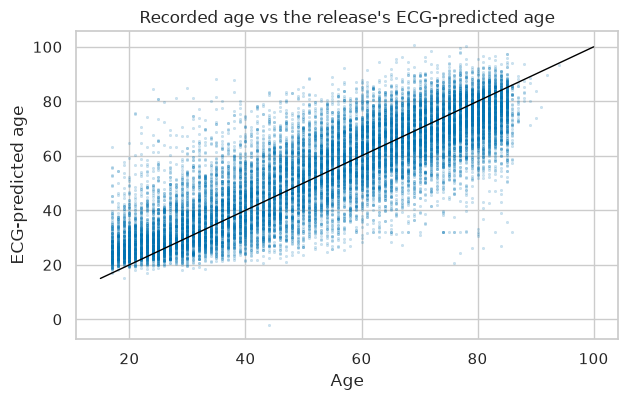

Correlation of recorded and ECG-predicted age: 0.832


In [5]:
ratios = odds_ratios(exams, [*LABELS, "normal_ecg"])
ratios["outcome"] = ratios["outcome"].replace(NAMES)
display(ratios.round(3))
fig, ax = plt.subplots(figsize=(7, 4))
sample = exams.sample(20000, random_state=0)
sns.scatterplot(sample, x="age", y="nn_predicted_age", s=4, alpha=0.2, edgecolor=None, ax=ax)
ax.plot([15, 100], [15, 100], color="black", linewidth=1)
ax.set(title="Recorded age vs the release's ECG-predicted age", xlabel="Age", ylabel="ECG-predicted age")
plt.show()
correlation = exams[["age", "nn_predicted_age"]].corr().iloc[0, 1]
print(f"Correlation of recorded and ECG-predicted age: {correlation:.3f}")

**Finding: sparse labels with clear age and sex patterns.**

- The six flags are rare (1.6-2.8% each). `normal_ecg` (39%) never co-occurs with them, and **half of all
  exams (50%) are neither normal nor one of the six**: they are abnormal in some way the release does not
  describe.
- **Atrial fibrillation** and **left bundle branch block** rise fastest with age (odds about 2x per decade).
  **Sinus bradycardia** is three times more likely in men, while **left bundle branch block** is slightly
  *less* likely in men, the same pattern as in Georgia and CPSC. **Sinus tachycardia** becomes slightly less
  common with age.
- The share of normal ECGs falls with age.
- The ECG-predicted age tracks the recorded age closely (correlation 0.83), so the ECG carries a lot of
  information about age.

## 3. Mortality

About two thirds of exams have follow-up: whether the patient died, and after how long (`timey`, years).
How does death relate to age, sex, the diagnosis flags and the ECG-predicted age?

,count,mean,std,min,25%,50%,75%,max
follow-up (years),233647.0,3.68,1.87,0.0,2.1,3.46,5.21,7.68


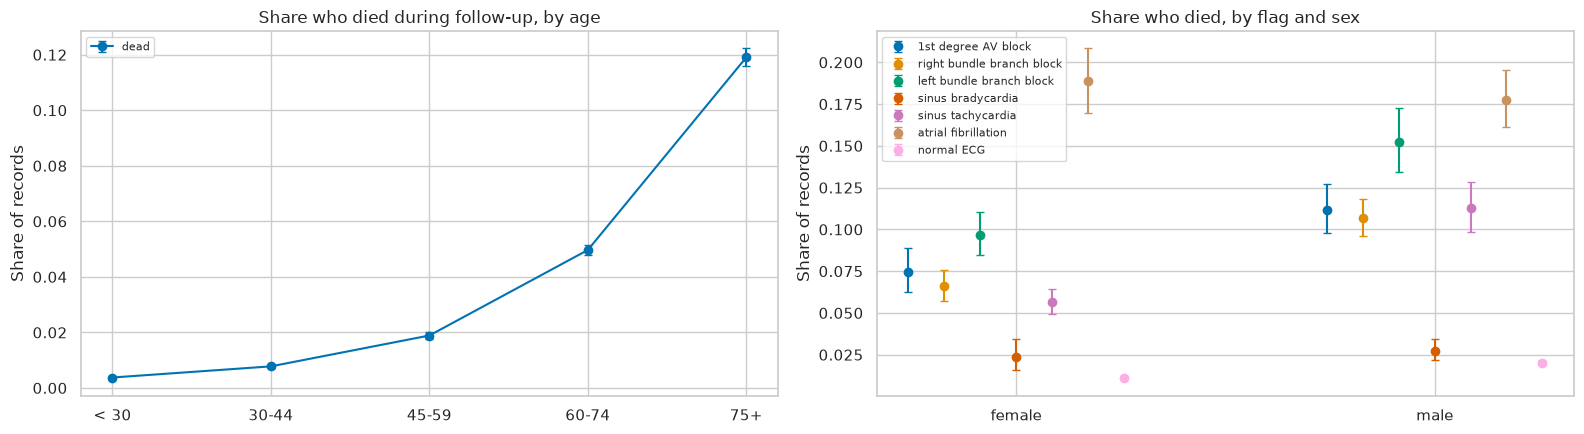

,share who died
atrial fibrillation,0.182
left bundle branch block,0.119
1st degree AV block,0.094
right bundle branch block,0.087
sinus tachycardia,0.075
other abnormal,0.042
sinus bradycardia,0.026
normal ECG,0.015


In [6]:
followed = exams[exams["dead"].notna()].copy()
display(followed["timey"].describe().round(2).to_frame("follow-up (years)").T)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
death_by_age = prevalence(followed, "age_band", ["dead"])
plot_prevalence(death_by_age, "age_band", axes[0], "Share who died during follow-up, by age")
flagged = pd.concat([prevalence(followed[followed[label]], "sex", ["dead"]).assign(outcome=NAMES[label])
                     for label in LABELS])
normal = prevalence(followed[followed["normal_ecg"]], "sex", ["dead"]).assign(outcome="normal ECG")
plot_prevalence(pd.concat([flagged, normal]), "sex", axes[1], "Share who died, by flag and sex",
                connect=False)
plt.tight_layout()
plt.show()
death_by_flag = pd.Series({NAMES[label]: followed.loc[followed[label], "dead"].mean() for label in LABELS})
death_by_flag["normal ECG"] = followed.loc[followed["normal_ecg"], "dead"].mean()
death_by_flag["other abnormal"] = followed.loc[~followed["any_flag"] & ~followed["normal_ecg"], "dead"].mean()
display(death_by_flag.sort_values(ascending=False).round(3).to_frame("share who died"))

In [7]:
display(odds_ratios(followed, ["dead"]).round(3))
followed["age_gap"] = followed["nn_predicted_age"] - followed["age"]
followed["gap_group"] = pd.cut(followed["age_gap"], [-100, -8, 8, 100],
                               labels=["ECG 8+ years younger", "within 8 years", "ECG 8+ years older"])
display(followed.groupby("gap_group", observed=True)["dead"].agg(["size", "mean"]).round(3)
        .rename(columns={"size": "exams", "mean": "share who died"}))
by_band = followed.pivot_table(index="age_band", columns="gap_group", values="dead", aggfunc="mean",
                               observed=True)
by_band["median ECG-age gap (years)"] = followed.groupby("age_band", observed=True)["age_gap"].median()
display(by_band.round(3))
model_data = followed.assign(male=followed["male"].astype(float))
fit = smf.logit("dead ~ I(age / 10) + male + I(age_gap / 10)", model_data).fit(disp=False)
adjusted = pd.DataFrame({"odds_ratio": np.exp(fit.params), "lower": np.exp(fit.conf_int()[0]),
                         "upper": np.exp(fit.conf_int()[1]), "p_value": fit.pvalues}).drop("Intercept")
display(adjusted.round(3))

,outcome,predictor,odds_ratio,lower,upper,p_value
0,dead,age per 10 years,1.958,1.926,1.991,0.0
1,dead,male,1.658,1.585,1.734,0.0


,exams,share who died
gap_group,,
ECG 8+ years younger,43121,0.046
within 8 years,134126,0.035
ECG 8+ years older,56400,0.030


gap_group,ECG 8+ years younger,within 8 years,ECG 8+ years older,median ECG-age gap (years)
age_band,,,,
< 30,0.000,0.002,0.006,6.014
30-44,0.004,0.005,0.015,1.482
45-59,0.010,0.016,0.032,1.189
60-74,0.036,0.048,0.072,-0.603
75+,0.106,0.124,0.157,-4.935


,odds_ratio,lower,upper,p_value
I(age / 10),2.123,2.085,2.162,0.0
male,1.634,1.562,1.709,0.0
I(age_gap / 10),1.348,1.317,1.380,0.0


**Finding: death follows age, sex and the ECG, and the ECG-age gap shows why adjustment matters.**

- Follow-up lasts a median of 3.5 years (up to 7.7). The share who died rises from 0.4% under 30 to 12% at 75
  and over. After adjusting for age, men have about 1.65 times the odds of dying.
- Among the flags, **atrial fibrillation** has the highest mortality (18%), followed by left bundle branch
  block (12%). Exams read as **normal** have the lowest (1.5%). The large "other abnormal" group (4.2%) sits in
  between.
- **The ECG-age gap is a clean example of Simpson's paradox.** Unadjusted, patients whose ECG looks 8+ years
  *older* than their age die *less* often than the rest (3.0% vs 4.6% for ECGs that look younger). But within
  every age band, the older-looking ECGs have the *highest* mortality. The unadjusted comparison is driven by
  age: the model tends to overestimate the age of young patients, who rarely die. After adjusting for age and
  sex, each 10 years of "ECG age" above the real age multiplies the odds of death by about 1.35.

These are associations over a few years of follow-up in one telehealth population, not causal effects.

## 4. Stored tracings versus the exam table

In [8]:
padding = padding_table()
known = padding["exam_id"].isin(exams.index)
display(pd.Series({
    "stored tracings (all parts)": len(padding),
    "distinct exam IDs stored": padding["exam_id"].nunique(),
    "stored rows with exam_id 0 (not in exams.csv)": int((padding["exam_id"] == 0).sum()),
    "stored rows with any other unknown exam ID": int((~known & (padding["exam_id"] != 0)).sum()),
    "exams in exams.csv without a stored tracing": int((~exams.index.isin(padding["exam_id"])).sum()),
    "filler rows that are all zero":
        int(((padding["exam_id"] == 0) & (padding["active_samples"] == 0)).sum()),
}).to_frame("count"))

,count
stored tracings (all parts),345797
distinct exam IDs stored,345780
stored rows with exam_id 0 (not in exams.csv),18
stored rows with any other unknown exam ID,0
exams in exams.csv without a stored tracing,0
filler rows that are all zero,18


**Finding: the tracings and the exam table match one to one.** Every exam has exactly one stored tracing. The
18 extra rows are one all-zero filler row per part with `exam_id` 0, a known quirk of the release. Any loader
must drop them.

## 5. Duration: what the zero padding tells us

Every tracing is stored as 4,096 samples (10.24 s at 400 Hz). Shorter recordings are padded with zeros. We
measure the zero rows at the start and end of every tracing.

,tracings,share
active_samples,,
all zero,688,0.002
< 5 s,1300,0.004
5-7.3 s,3099,0.009
"exactly 2,934",201084,0.582
7.3-10.24 s,8863,0.026
"exactly 4,096",130763,0.378


2,934-sample tracings padded exactly 581 + 581: 99.99%


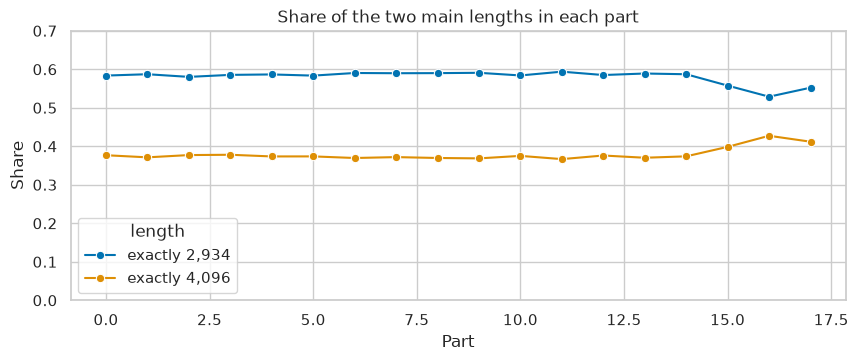

In [9]:
groups = pd.cut(padding["active_samples"], [-1, 0, 1999, 2933, 2934, 4095, 4096],
                labels=["all zero", "< 5 s", "5-7.3 s", "exactly 2,934", "7.3-10.24 s", "exactly 4,096"])
counts = groups.value_counts().sort_index()
display(pd.DataFrame({"tracings": counts, "share": (counts / counts.sum()).round(4)}))
centered = padding[padding["active_samples"] == 2934]
share_centered = ((centered["left"] == 581) & (centered["right"] == 581)).mean()
print(f"2,934-sample tracings padded exactly 581 + 581: {share_centered:.2%}")
by_part = pd.crosstab(padding["part"], groups, normalize="index")[["exactly 2,934", "exactly 4,096"]]
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.lineplot(by_part.reset_index().melt(id_vars="part", var_name="length", value_name="share"),
             x="part", y="share", hue="length", marker="o", ax=ax)
ax.set(title="Share of the two main lengths in each part", xlabel="Part", ylabel="Share", ylim=(0, 0.7))
plt.show()

**Finding: two recording lengths.** 58% of tracings have exactly 2,934 non-zero samples (7.3 s), centered with
581 zeros on each side in 99.99% of cases, and 38% fill all 4,096 samples (10.24 s). About 4% fall elsewhere,
and 0.2% are all zero. The mix is the same in every part (parts 15-17 have slightly more full-length
tracings), so it is a property of the dataset. In most exams, 28% of the stored samples are padding.

In [10]:
summary = code15_summary().join(exams, on="exam_id")
summary["length"] = np.where(summary["active_samples"] == 4096, "4,096 samples", "shorter")
display(problem_counts(summary).to_frame("tracings with at least 5 s of signal"))
medians = ["baseline_fraction", "high_frequency_fraction", "std", "peak_abs_mv", "heart_rate", "age"]
display(summary.groupby("length")[medians].median().round(4))
identities = ["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]
summary["limb_violated"] = summary[identities].max(axis=1) > 0.05
shares = summary.assign(large=summary["large_leads"] > 0, flat=summary["flat_leads"] > 0)
shares = shares.groupby("length")[["large", "flat", "limb_violated", "normal_ecg"]].mean()
display(shares.rename(columns={"large": "any lead over 10 units", "flat": "any lead flat 1 s",
                               "limb_violated": "limb identity violated"}).round(3))

,tracings with at least 5 s of signal
records,343809
any_nan,0
fully_constant_lead,1062
lead_flat_for_1s,5504
lead_over_10mv,40037
limb_identity_violated,80546
heart_rate_not_estimated,420


,baseline_fraction,high_frequency_fraction,std,peak_abs_mv,heart_rate,age
length,,,,,,
"4,096 samples",0.201,3.000e-04,0.404,5.685,70.588,54.0
shorter,0.005,2.600e-03,0.281,3.650,71.217,55.0


,any lead over 10 units,any lead flat 1 s,limb identity violated,normal_ecg
length,,,,
"4,096 samples",0.199,0.017,0.015,0.419
shorter,0.066,0.016,0.369,0.374


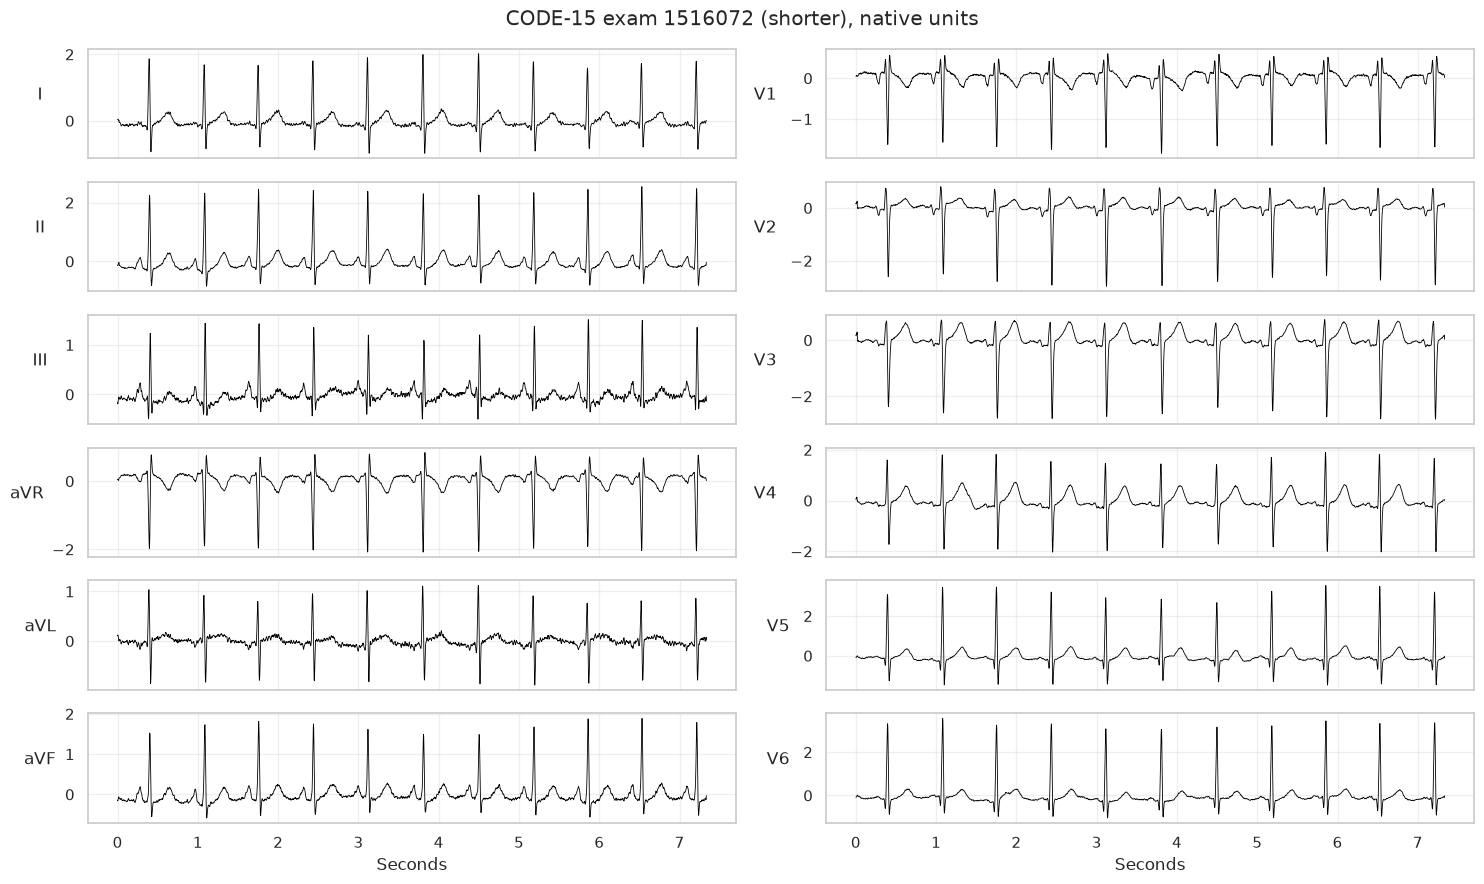

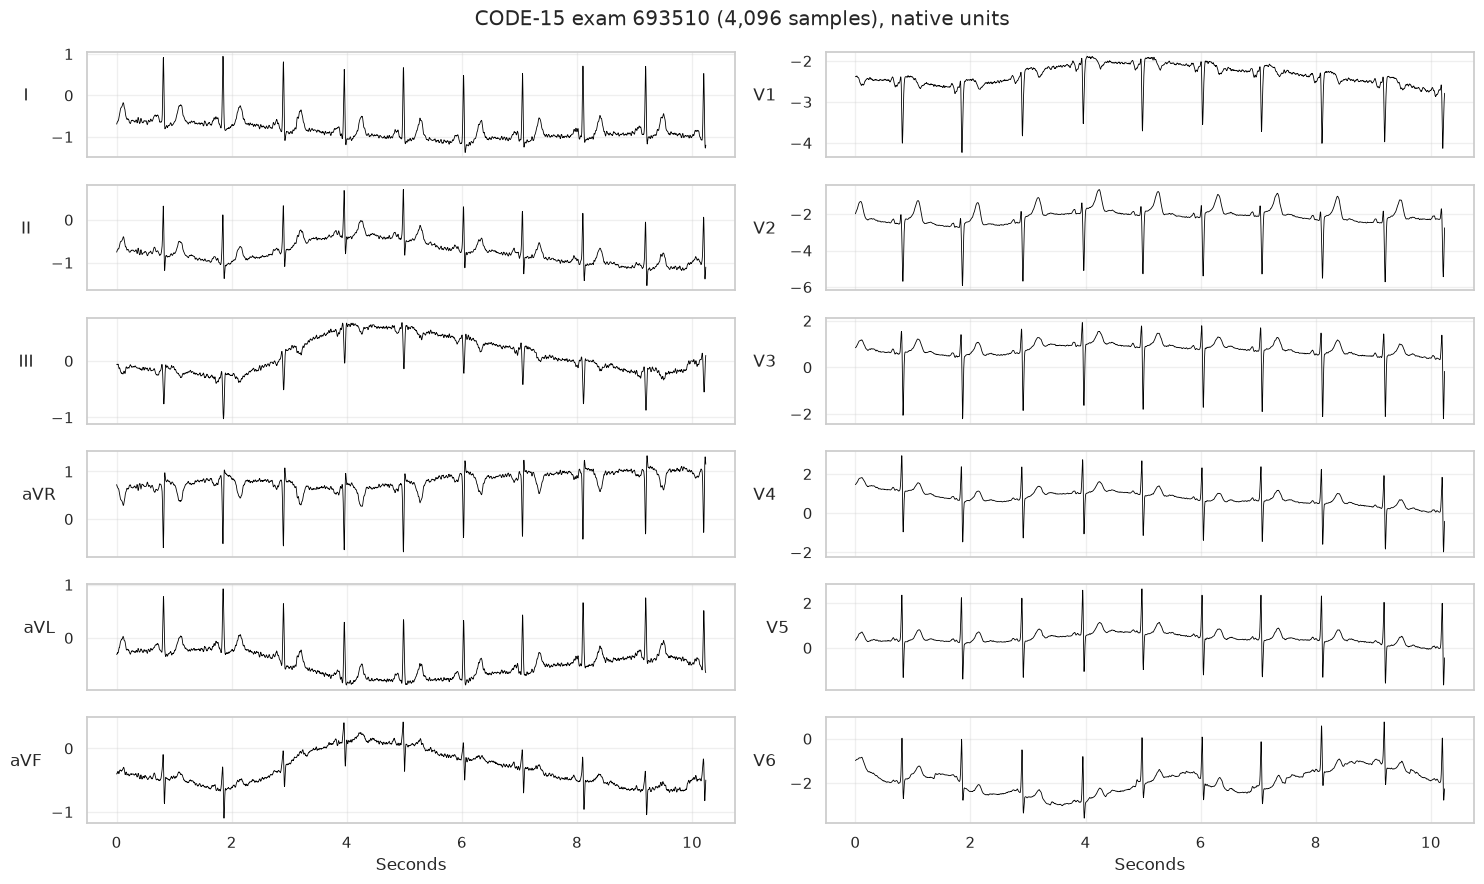

In [11]:
native_ids = set(pd.read_csv(PREPARED_DIR / "part0_native/manifest.csv")["exam_id"])
part0 = summary[(summary["part"] == 0) & summary["exam_id"].isin(native_ids)]
for group in ["shorter", "4,096 samples"]:
    row = part0[part0["length"] == group].sample(1, random_state=1).iloc[0]
    tracing = read_native_tracing(int(row["exam_id"]))
    active = tracing[int(row["left"]):len(tracing) - int(row["right"])]
    plot_ecg(active, 400, f"CODE-15 exam {int(row['exam_id'])} ({group}), native units", seconds=10.24)
    plt.show()

**Finding: the two lengths look like two acquisition pipelines.** The full-length tracings have about 36x more
low-frequency power, much less high-frequency power, larger amplitudes, and a lead above 10 units in 20% of
tracings (against 7%). The shorter ones look filtered; the long ones look raw, with baseline wander. The
shorter group also breaks a limb-lead identity in 37% of tracings against 2%, which suggests its leads were
processed separately. Age and heart rate barely differ, so this is acquisition rather than population. The
length group is a covariate that any analysis should keep.

## 6. Amplitude unit

If the stored values were mV, their amplitudes should resemble the other five sources, all of which are
confirmed mV. We compare the signal range (99th minus 1st percentile) per lead with PTB-XL, restricted to
ages 40-59 so that age does not explain the difference.

,CODE-15,PTB-XL,ratio
lead,,,
I,1.628,0.810,2.009
II,1.756,0.806,2.179
III,1.221,0.596,2.049
aVR,1.604,0.766,2.094
aVL,1.155,0.577,2.002
aVF,1.260,0.571,2.206
V1,1.947,0.973,2.001
V2,2.511,1.586,1.583
V3,2.932,1.555,1.885


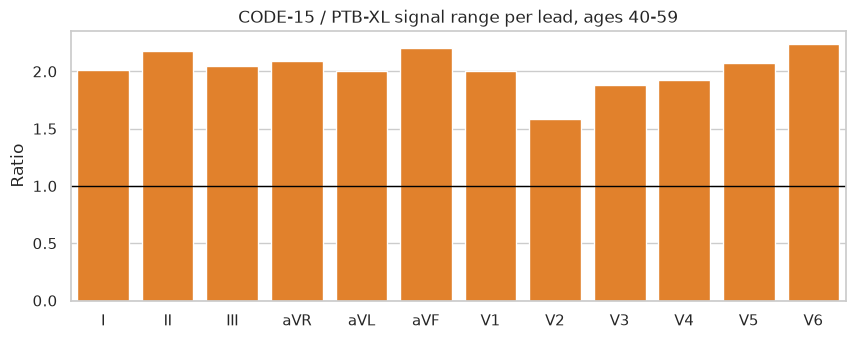

,median signal std (native units)
source,
mimic,0.133
georgia,0.143
cpsc_2018_extra,0.144
cpsc_2018,0.149
chapman_shaoxing,0.151
ptbxl,0.152
code15,0.316


In [12]:
code15_leads = lead_features().join(exams["age"], on="exam_id")
ptbxl_leads = pd.read_parquet(PTBXL_FEATURES)
ptbxl_leads["ecg_id"] = ptbxl_leads["record_id"].astype(int)
ptbxl_leads = ptbxl_leads.join(load_metadata()["age"], on="ecg_id")
ranges = {}
for name, table in (("CODE-15", code15_leads), ("PTB-XL", ptbxl_leads)):
    middle_aged = table[(table["age"] >= 40) & (table["age"] < 60)]
    ranges[name] = (middle_aged["p99"] - middle_aged["p01"]).groupby(middle_aged["lead"]).median()
ranges = pd.DataFrame(ranges).loc[LEADS]
ranges["ratio"] = ranges["CODE-15"] / ranges["PTB-XL"]
display(ranges.round(3))
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.barplot(x=ranges.index, y=ranges["ratio"], ax=ax, color="tab:orange")
ax.axhline(1, color="black", linewidth=1)
ax.set(title="CODE-15 / PTB-XL signal range per lead, ages 40-59", xlabel="", ylabel="Ratio")
plt.show()
spread = combined_summary().groupby("source")["std"].median().sort_values()
display(spread.to_frame("median signal std (native units)").round(3))

**Finding: the stored values are about twice as large as millivolts, uniformly across leads.** For the same
ages, every lead's range is 1.6-2.2 times PTB-XL's (median 2.03), and the median signal standard deviation is
about twice that of all five mV sources, which agree closely with each other. A physiological difference would
change limb and precordial leads differently. A uniform factor of about 2 points to a scale difference in
storage. CODE-15 amplitudes cannot be compared with other datasets until they are rescaled, and the factor
should be confirmed with the dataset authors.

## 7. Checking the sampling rate with the labels

If the stated 400 Hz were wrong, every estimated heart rate would be off by the same factor. The sinus
tachycardia and bradycardia flags are defined by rate (above 100 and below 60 bpm), which gives an independent
check.

In [13]:
rates = pd.DataFrame({NAMES[flag]: summary.groupby(flag)["heart_rate"].median()
                      for flag in ["ST", "SB", "AF"]}).T
rates.columns = ["flag absent", "flag present"]
display(rates.round(1))

,flag absent,flag present
sinus tachycardia,70.6,108.1
sinus bradycardia,71.2,47.2
atrial fibrillation,70.8,87.0


**Finding: 400 Hz is correct.** Exams flagged sinus tachycardia have a median estimated heart rate of about 108
bpm, and exams flagged sinus bradycardia about 47 bpm, on the right side of the 100 and 60 bpm definitions.
Unflagged exams sit around 71 bpm. The flags and the waveforms are consistent.

## 8. Conclusions about the dataset

- **Structure.** 345,779 exams from 233,770 patients (29% with repeats), younger (median 54) and mostly female
  (60%). Every exam has one stored tracing; 18 filler rows and 688 all-zero tracings must be dropped.
- **Missing values.** Only mortality follow-up is missing (32%), more often for older patients.
- **Labels.** Six rare flags plus an automatic normal flag, which leaves half the exams "abnormal, unspecified".
  Atrial fibrillation and LBBB rise steeply with age; sinus bradycardia is male-dominated; LBBB is not.
- **Mortality.** Death rises steeply with age, is higher in men, and is highest after atrial fibrillation (18%).
  An ECG that looks older than the patient predicts higher mortality, but only once age is adjusted for; the
  unadjusted comparison points the wrong way.
- **Tracings.** Two recording lengths (7.3 s and 10.24 s) that look like different acquisition pipelines. The
  stored values are about 2x millivolts. The sampling rate is confirmed at 400 Hz.

The last notebook compares all six sources.